# Detect and Remove Features Highly Correlated with the KPI

In this notebook, we begin by loading the clean dataset obtained from the preprocessing stage. Then, this phase involves detecting and removing features that are highly correlated with the Key Performance Indicator (KPI). 

In this case, we utilize various functions from the ``scikit-learn`` library, a Python library that supports many supervised and unsupervised machine learning techniques. Additionally, we employ the ``matplotlib`` library, which provides several visualization tools to display our results.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn import mixture

import warnings
warnings.filterwarnings('ignore')

## Loading the Clean Dataset

This stage loads the clean dataset generated by the preprocessing module.

In [2]:
print('-----------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file = 'data/Op1_CapDL_NoSteps.csv'
data = pd.read_csv(data_file, sep=",", decimal='.', low_memory = False)
data = data.drop(columns=['Unnamed: 0'])
print('Data Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------')
target_kpi = 'transfer.datarate'
kpi_aux    = data[target_kpi]
data.describe()

-----------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
Data Size:(1001, 134)
-----------------------------------------


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,actual.data.bytes.b2a,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,pushed.data.pkts.b2a,...,abs.instanttp.75.,abs.instanttp.max,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.25.,abs.theoricalmaxtp.50.,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.75.,abs.theoricalmaxtp.max,transfer.datarate
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1.001000e+03,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1.001000e+03,1.001000e+03
mean,128.041958,23504.771229,19.445554,0.000999,645.926074,3.633937e+08,2.017982,2.334520e+06,1028.684316,12308.755245,...,491.758768,741.466738,63.993007,236.949051,441.625503,561.372499,6.736559e+09,710.863775,3.329800e+13,3.934347e+05
std,95.049736,11232.441681,35.021355,0.031607,3311.848603,1.816432e+08,46.315242,7.746871e+06,4453.186531,4153.813206,...,226.283063,297.944038,159.287303,1485.634821,233.282453,280.155248,1.424162e+10,348.507113,2.990747e+13,1.984722e+05
min,0.000000,1299.000000,5.000000,0.000000,0.000000,2.530626e+06,0.000000,0.000000e+00,0.000000,229.000000,...,3.357520,8.971200,0.000000,0.000000,1.577791,2.184153,2.317959e+00,2.650657,9.010940e+00,2.408967e+03
25%,62.000000,18357.000000,6.000000,0.000000,0.000000,2.339057e+08,0.000000,0.000000e+00,32.000000,9796.000000,...,332.409600,541.194240,0.000000,0.000000,270.515163,354.645581,9.986515e+02,460.914598,6.019258e+04,2.530839e+05
50%,117.000000,23260.000000,9.000000,0.000000,23.000000,3.482581e+08,0.000000,1.081380e+05,75.000000,12746.000000,...,479.229920,767.104400,13.000000,3.000000,424.008163,541.358703,2.691650e+09,678.650452,3.004338e+13,3.813481e+05
75%,176.000000,27219.000000,17.000000,0.000000,185.000000,4.789645e+08,0.000000,1.393763e+06,322.000000,14987.000000,...,634.784640,935.788080,53.000000,26.000000,597.308615,743.697358,7.241105e+09,934.029041,5.818665e+13,5.196789e+05
max,748.000000,105106.000000,521.000000,1.000000,31047.000000,1.163245e+09,1397.000000,8.789408e+07,41515.000000,26067.000000,...,1443.523040,1818.965520,1956.000000,15336.000000,1539.051243,2156.812000,1.970290e+11,2955.655695,1.836066e+14,1.275028e+06


## Detection and Removal of Features Correlated with the KPI

Features correlated to the KPI typically induce overfitting in machine-learning models, leading to erroneous interpretations. In this stage, we aim to detect and remove features highly correlated with the KPI at this stage. To this end, we build the vector of correlation factors, where each entry is computed as follows:

$$ c_i = 1 - \left| \frac{\mathbf{cov}(\mathbf{x}_i, \mathbf{y})}{\sigma_{\mathbf{x}_i} \sigma_{\mathbf{y}}} \right|$$

where $\mathbf{y}$ is target KPI vector and $\mathbf{x}_i$ denotes a vector describing the $i$-th feature, $\sigma_{\mathbf{x}_i}$ is the standard deviation of the $i$-th feature, and $\sigma_{\mathbf{y}}$ is the standard deviation of the target KPI. Notice that every correlation factor $c_i$ can be described as one minus the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) between the target KPI and the $i$-th feature. In practical terms, we compute the correlation factor matrix (one minus the Pearson correlation matrix) and extract the vector corresponding to the target KPI.

In [3]:
# Compute the matrix of correlation factors and extract the vector related to the target KPI 
corr_matrix = 1 - data.corr(method='pearson').abs()
corr_vector = corr_matrix[target_kpi].to_numpy().reshape(-1,1)

## Gaussian Mixture

In this work, we use a clustering method based on Gaussian mixture models (GMMs) to identify features highly correlated with the KPI. In particular, a GMM assumes that the data entries are random samples generated by a mixture of a finite number of Gaussian distributions, each with different parameters. We implement the GMM-based clustering with the `mixture.GaussianMixture` function of the scikit-learn library. This method estimates the parameters of the Gaussian distributions using an Expectation-Maximization (EM) algorithm. Furthermore, it assigns each test data point to the most likely Gaussian distribution, where each Gaussian model represents a different cluster. 

It is essential to mention that the optimal number of clusters that best describe data is not known. Furthermore, this method uses a random seed to select the method to initialize the parameters, which can result in different outcomes even when the same input data is used. To overcome this limitation, we implement a Monte Carlo approximation to detect the optimal number of clusters according to the Bayesian Information Criterion. More precisely, we estimate the average BIC curve along the number of clusters and detect the number of clusters that generate the minimum average BIC value. After determining the optimal number of clusters, we identify and remove features associated with the cluster that has the lowest centroid.


In [4]:
eval_window = 40
iterations  = 50

# Monte Carlo Approximation to estimate the average BIC curve
max_num_clusters = np.min([eval_window + 1, len(corr_vector)])
bic_ite    = np.zeros((iterations, max_num_clusters - 1))
rand_stt   = np.random.randint(2**16, size=(iterations, max_num_clusters - 1)) 
for ii in range(iterations):
    for jj in range(1, max_num_clusters):
        gmm = mixture.GaussianMixture(n_components = jj,
                                      random_state = rand_stt[ii,jj-1])
        gmm.fit(corr_vector)
        bic_ite[ii,jj-1] = gmm.bic(corr_vector)
        
# Determining the optimal number of clusters
num_opt_clusters_bic = np.argmin(np.mean(bic_ite, axis=0)) + 1
minbic = np.min(np.mean(bic_ite, axis=0))
maxbic = np.max(np.mean(bic_ite, axis=0))

# Implement the optimal model
lowest_bic  = np.infty
bic         = []
for ii in range(iterations):
    gmm_bic = mixture.GaussianMixture(num_opt_clusters_bic,
                                      random_state = rand_stt[ii,num_opt_clusters_bic-1])
    gmm_bic.fit(corr_vector)
    bic.append(gmm_bic.bic(corr_vector))
    if bic[-1] < lowest_bic:
        lowest_bic = bic[-1]
        best_gmmb = gmm_bic
    clusters_bic = best_gmmb.predict(corr_vector)
    centroids_bic = best_gmmb.means_

# Identify the features highly correlated with the KPI
columns_to_remove_bic = data.columns[(clusters_bic == np.argmin(centroids_bic))]

data1 = data.copy()
if (len(np.unique(clusters_bic)) > 1):
    data1 = data1.loc[:, data1.columns[(clusters_bic != np.argmin(centroids_bic))]]
data1[target_kpi] = kpi_aux

data1.to_csv('data/Op1_CapDL_NoSteps_wo_correlated_features.csv')

### Results of the Feature Removal using GMM-based clustering

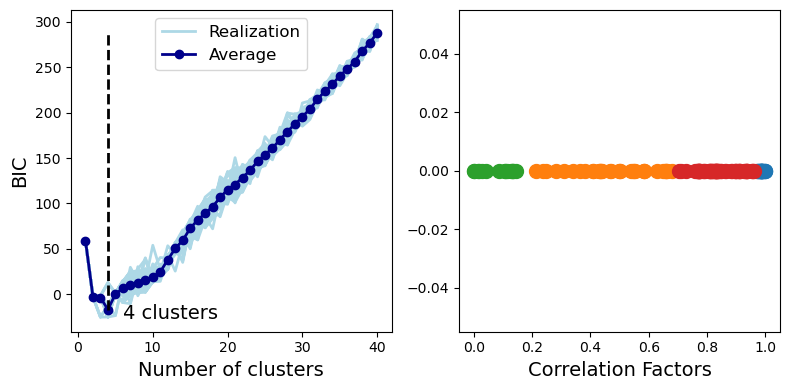

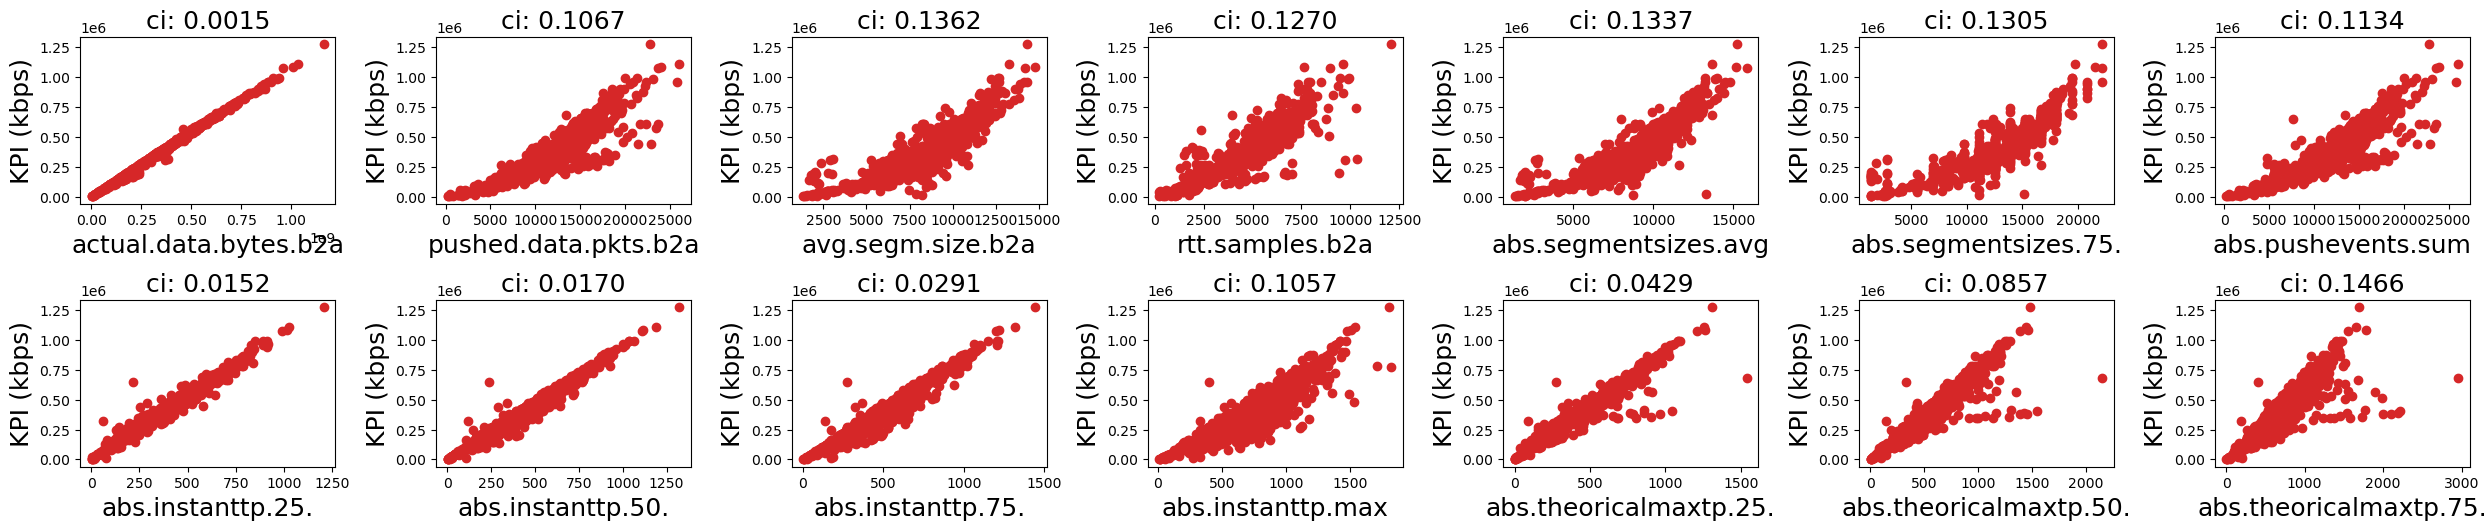

In [5]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,2,1)
for ii in range(iterations):
    if (ii ==0):
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue', label='Realization')
    else:
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue')
plt.plot(np.arange(1, max_num_clusters), np.mean(bic_ite, axis=0), '-o',lw=2, c='darkblue', label='Average')
plt.plot([num_opt_clusters_bic, num_opt_clusters_bic], [minbic, maxbic],'k--', lw=2)
plt.xlabel('Number of clusters', fontsize=14)
plt.ylabel('BIC', fontsize=14)
plt.text(num_opt_clusters_bic + 2, np.mean(bic_ite, axis=0)[num_opt_clusters_bic-1]-10, str(num_opt_clusters_bic) + ' clusters', fontsize=14)
plt.legend(fontsize=12, loc='upper center')

ax  = fig.add_subplot(1,2,2)
for i in range(len(np.unique(clusters_bic))):
    plt.scatter(corr_vector[clusters_bic == i], np.zeros(len(corr_vector[clusters_bic == i])), s=100)
plt.xlabel('Correlation Factors', fontsize=14)
    
fig.tight_layout()
plt.show()


ncols = 7
nrows = ((len(columns_to_remove_bic) - 1) // ncols) + 1
fig = plt.figure(figsize=(25,2.50*nrows), tight_layout=True)
for ii in range(len(columns_to_remove_bic)-1):
    ax = fig.add_subplot(nrows,ncols,ii+1)
    plt.plot(data[columns_to_remove_bic[ii]], data[target_kpi],'o', color='tab:red')
    plt.xlabel(columns_to_remove_bic[ii], fontsize=18)
    plt.ylabel('KPI (kbps)', fontsize=18)
    plt.title('ci: %.4f'%(corr_matrix[columns_to_remove_bic[ii]][-1]), fontsize=18)
fig.tight_layout()
plt.show()